In [62]:
import os

import cv2
import matplotlib.pyplot as plt 
import numpy as np
from tensorflow.keras.models import load_model

In [3]:
ROOT = os.path.dirname(os.getcwd())
MODELS_PATH = os.path.join(ROOT, 'models')
DATA_PATH = os.path.join(ROOT, 'data', 'test')

In [6]:
model = load_model(os.path.join(MODELS_PATH, 'digit_recognition.keras'))

In [70]:
imgs = []
labels = []

for label in os.listdir(DATA_PATH):
    img_path = os.path.join(DATA_PATH, label)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    _, img = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)

    img = img[y:y+h, x:x+w]

    if h > w:
        new_h = 20
        new_w = int(w * 20 / h)
    else:
        new_w = 20
        new_h = int(h * 20 / w)

    img = cv2.resize(img, (new_w, new_h))

    canvas = np.zeros((28, 28), dtype=np.uint8)

    x_offset = (28 - new_w) // 2
    y_offset = (28 - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img

    img = canvas.astype("float32")
    img /= 255.0
    img = np.expand_dims(img, -1)

    imgs.append(img)
    labels.append(label[0])

imgs = np.array(imgs)

In [71]:
prediction_probability = model.predict(imgs)
prediction = np.argmax(prediction_probability, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [72]:
print(prediction)
print(labels)

[3 6 2]
['3', '6', '7']


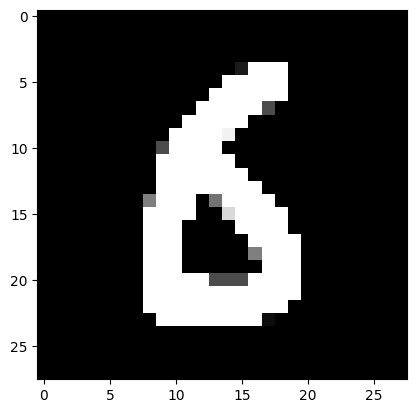

In [74]:
plt.imshow(imgs[1], cmap='gray')